<a href="https://colab.research.google.com/github/hsultova/Softuni-AI-Integrations/blob/main/regular_exam_hsultova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [3]:
%pip install -q openai chromadb pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/6

In [36]:
import base64
import json
import re
import time

from pathlib import Path
from pprint import pprint
from typing import List, Literal, Optional

from pydantic import BaseModel, Field
from pypdf import PdfReader

from IPython.display import Audio, Image, display

from chromadb import PersistentClient
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction
from openai import OpenAI

from google.colab import userdata

# AI models and client initialization

In [8]:
OPENAI_TEXT_MODEL = "gpt-4.1-nano"
OPENAI_TEXT_MODEL_MINI = "gpt-4.1-mini"
OPENAI_IMAGE_MODEL = "gpt-image-1-mini"
OPENAI_SPEECH_MODEL = "gpt-4o-mini-tts"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

In [9]:
openai_api_key = userdata.get('OpenAI_API_key')
openai_client = OpenAI(api_key=openai_api_key)

# Extract content from the pdf file

In [10]:
import gdown
gdown.download(id="1zGCLhuCdCciNflzPBmQVgY_QfFoGQlvN", output="/content/Recipe_collection.pdf", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1zGCLhuCdCciNflzPBmQVgY_QfFoGQlvN
To: /content/Recipe_collection.pdf
100%|██████████| 715k/715k [00:00<00:00, 7.37MB/s]


'/content/Recipe_collection.pdf'

In [11]:
path_to_pdf = Path("/content/Recipe_collection.pdf")

if not path_to_pdf.exists():
  raise FileNotFoundError(f"The file {path_to_pdf} does not exist.")

pdf_reader = PdfReader(path_to_pdf)
print(f"Reading {path_to_pdf}")

Reading /content/Recipe_collection.pdf


In [12]:
text_fragments = [page.extract_text() or "" for page in pdf_reader.pages]
text = '\n'.join(text_fragments)
print(f"Extracted {len(text_fragments)} pages from {path_to_pdf}")

Extracted 30 pages from /content/Recipe_collection.pdf


# Create ChromaDb collection

In [13]:
PATH_TO_CHROMA = "/content/db"
chroma_client = PersistentClient(path=PATH_TO_CHROMA)

In [14]:
chroma_collection = chroma_client.get_or_create_collection(
    name="recipe_collection",
    embedding_function=OpenAIEmbeddingFunction(
        api_key=openai_api_key,
        model_name=OPENAI_EMBEDDING_MODEL))

print(f"The chroma collection with name '{chroma_collection.name}' was created successfully.")

The chroma collection with name 'recipe_collection' was created successfully.


# Parse recipes

In [15]:
def parse_recipes(text):
    recipes = []

    # Find all positions of each keyword marker
    def find_all(text, keyword):
        positions = []
        start = 0
        while True:
            pos = text.find(keyword, start)
            if pos == -1:
                break
            positions.append(pos)
            start = pos + len(keyword)
        return positions

    ing_positions = find_all(text, "INGREDIENTS")
    prep_positions = find_all(text, "PREPARATION")
    gtk_positions = find_all(text, "GOOD TO KNOW")

    for i in range(len(ing_positions)):
        # --- HEADER: from previous GOOD TO KNOW to this INGREDIENTS ---
        header_start = gtk_positions[i - 1] + len("GOOD TO KNOW") if i > 0 else 0
        header = text[header_start:ing_positions[i]].strip()

        # Find recipe name: the line right before the origin line (which has ·)
        lines = [l.strip() for l in header.split("\n") if l.strip()]

        name = ""
        description = ""
        country = ""
        for j in range(len(lines) - 1):
            if "·" in lines[j + 1]:
                name = lines[j]
                origin_line = lines[j + 1]
                country = origin_line.split("·")[0].strip().title()
                description = " ".join(lines[j + 2:])
                break

        if not name:
            continue

        # --- INGREDIENTS: between INGREDIENTS and PREPARATION ---
        ingredients = text[ing_positions[i] + len("INGREDIENTS"):prep_positions[i]]
        ingredients = " ".join(ingredients.split())

        # --- PREPARATION: between PREPARATION and GOOD TO KNOW ---
        preparation = text[prep_positions[i] + len("PREPARATION"):gtk_positions[i]]
        preparation = " ".join(preparation.split())

        # --- FACT: from GOOD TO KNOW until next recipe starts ---
        fact_end = ing_positions[i + 1] if i + 1 < len(ing_positions) else len(text)
        fact_raw = text[gtk_positions[i] + len("GOOD TO KNOW"):fact_end].strip()

        # Trim off the next recipe's header that leaks into the fact
        fact_lines = []
        for line in fact_raw.split("\n"):
            line = line.strip()
            if not line:
                continue
            # Stop at next recipe's origin line (has ·)
            if "·" in line:
                if fact_lines:
                    fact_lines.pop()  # remove the recipe name that snuck in
                break
            # Stop at category headers like "02Soups & Salads"
            if len(line) >= 2 and line[0].isdigit() and line[1].isdigit():
                break
            fact_lines.append(line)

        fact = " ".join(" ".join(fact_lines).split())

        recipes.append({
            "name": name,
            "description": description,
            "ingredients": ingredients,
            "ingredients_lower": ingredients.lower(),
            "preparation": preparation,
            "fact": fact,
            "country": country.strip().lower()
        })

    return recipes


In [16]:
def to_document(recipe: dict) -> str:
    return (
        f"{recipe['name']} ({recipe['country'].title()})\n"
        f"{recipe['description']}\n"
        f"Ingredients: {recipe['ingredients']}\n"
        f"Preparation: {recipe['preparation']}\n"
        f"Good to know: {recipe['fact']}"
    )

In [17]:
def index_recipes(text: str):
    recipes = parse_recipes(text)

    chroma_collection.upsert(
        ids=[f"recipe_{i}" for i in range(len(recipes))],
        documents=[to_document(r) for r in recipes],
        metadatas=[{
            "name": recipe["name"],
            "description": recipe["description"],
            "ingredients": recipe["ingredients"],
            "preparation": recipe["preparation"],
            "ingredients_lower": recipe["ingredients_lower"],
            "fact": recipe["fact"],
            "country": recipe["country"]
        }
        for recipe in recipes],
    )

    return recipes

In [18]:
def print_recipes(recipes: List[dict]):
  for recipe in recipes:
    print()
    for key, value in recipe.items():
      print(f"{key}: {value}")

In [19]:
try:
  indexed = index_recipes(text)
  print(f"Indexed {len(indexed)} recipes successfully:")
  print_recipes(indexed)
except ValueError:
  print(f"Could not parse data.")

Indexed 24 recipes successfully:

name: Bruschetta al Pomodoro
description: Grilled bread rubbed with garlic and piled with ripe tomatoes, basil and olive oil — the purest expression of a summer harvest.
ingredients: 8 slices country bread 4 ripe tomatoes 2 garlic cloves 1 handful fresh basil 3 tbsp olive oil ½ tsp salt
ingredients_lower: 8 slices country bread 4 ripe tomatoes 2 garlic cloves 1 handful fresh basil 3 tbsp olive oil ½ tsp salt
preparation: 1. Dice ripe tomatoes, toss with salt and drain 10 minutes. 2. Grill thick slices of country bread until charred at the edges. 3. Rub each slice with a cut garlic clove. 4. Fold torn basil and olive oil into the tomatoes, then spoon on top.
fact: The name comes from bruscare, Roman dialect for "to roast over coals." Peasants used it to test the year's fresh-pressed olive oil.
country: italy

name: Hummus bi Tahini
description: A silken purée of chickpeas and sesame tahini, sharpened with lemon and garlic and pooled with green olive oil

# Tools implementation

In [20]:
class Recipe(BaseModel):
  name: str
  description: str
  ingredients: str
  preparation: str
  facts: str
  country: str

In [21]:
class LookupRecipeRequest(BaseModel):
    """
    Searches the recipe catalog by semantic similarity and returns the
    best-matching recipes. Use whenever the user asks about a recipe, its description,
    ingredients, preparation, country of origin, or facts.
    """
    query: str = Field(description="""
    A natural-language description of the recipe(s) wanted — by dish name,
    ingredient, course, country, or theme. Examples: 'Mochi', 'baked cheesecake',
    'all turkey recipes', 'a spicy soup'.""")
    top_n: int = Field(description="How many recipes to return, 1 to 20. Default to 5 when the user gives no number.")


In [22]:
class FilterRecipeRequest(BaseModel):
    """
    Filters the recipe catalog by exact attributes rather than semantic similarity.
    Use this tool when the user specifies precise constraints — a particular country
    of origin, ingredients the recipe must contain, or ingredients it must not
    contain. Prefer this over 'lookup_recipe' whenever the request is a hard filter
    ("all Italian recipes", "something without eggs") rather than an open-ended or
    descriptive search ("something warm and comforting").
    """
    country: Optional[str] = Field(
        default=None,
        description="Country of origin to match exactly, e.g. 'Italy', 'Turkey'. Leave empty if the user did not name a country."
    )
    include_ingredients: List[str] = Field(
        default_factory=list,
        description="Ingredients the recipe MUST contain. Each is a single ingredient name, e.g. ['chicken', 'garlic']. Empty if none specified."
    )
    exclude_ingredients: List[str] = Field(
        default_factory=list,
        description="Ingredients the recipe MUST NOT contain, e.g. ['eggs', 'nuts']. Empty if none specified."
    )
    top_n: int = Field(
        default=5,
        description="Maximum number of recipes to return, between 1 and 20. Use 5 when the user does not say how many they want."
    )


In [23]:
MAX_RESULTS = 20

In [24]:
def lookup_recipe(req: LookupRecipeRequest) -> List[Recipe]:
    n_results = max(1, min(req.top_n, MAX_RESULTS))

    lookup_result = chroma_collection.query(
        query_texts=[req.query],
        n_results=n_results,
        include=["metadatas", "documents"]
    )

    results_count = len(lookup_result["ids"][0])

    return [Recipe(
        name=lookup_result["metadatas"][0][i]["name"],
        description=lookup_result["metadatas"][0][i]["description"],
        ingredients=lookup_result["metadatas"][0][i]["ingredients"],
        preparation=lookup_result["documents"][0][i],
        facts=lookup_result["metadatas"][0][i]["fact"],
        country=lookup_result["metadatas"][0][i]["country"]
    ) for i in range(results_count)]

In [25]:
def filter_recipe(req: FilterRecipeRequest) -> List[Recipe]:
    n_results = max(1, min(req.top_n, MAX_RESULTS))

    where = None
    if req.country:
        where = {"country": req.country.strip().lower()}

    result = chroma_collection.get(
        where=where,
        include=["metadatas", "documents"],
    )

    metadatas = result["metadatas"]
    documents = result["documents"]

    include = [t.strip().lower() for t in req.include_ingredients if t.strip()]
    exclude = [t.strip().lower() for t in req.exclude_ingredients if t.strip()]

    def has_term(ingredients_lower: str, term: str) -> bool:
        # word-boundary match so "egg" does not match "eggplant"
        return re.search(rf"\b{re.escape(term)}\b", ingredients_lower) is not None

    recipes = []
    for meta, doc in zip(metadatas, documents):
        ing_lower = meta.get("ingredients_lower", "")

        if any(not has_term(ing_lower, t) for t in include):
            continue  # missing a required ingredient
        if any(has_term(ing_lower, t) for t in exclude):
            continue  # contains an excluded ingredient

        recipes.append(Recipe(
            name=meta["name"],
            description=meta["description"],
            ingredients=meta["ingredients"],
            preparation=doc,
            facts=meta["fact"],
            country=meta["country"],
        ))

        if len(recipes) >= n_results:
            break

    return recipes

In [26]:
lookup_recipe_tool_schema = LookupRecipeRequest.model_json_schema()
filter_recipe_tool_schema = FilterRecipeRequest.model_json_schema()

tools = [
    {
        "type": "function",
        "name": "lookup_recipe",
        "description": lookup_recipe_tool_schema["description"],
        "parameters": {
            "type": "object",
            "properties": lookup_recipe_tool_schema["properties"],
            "required": list(lookup_recipe_tool_schema["properties"].keys()),
            "additionalProperties": False
        },
        "strict": True
    },
    {
        "type": "function",
        "name": "filter_recipe",
        "description": filter_recipe_tool_schema["description"],
        "parameters": {
            "type": "object",
            "properties": filter_recipe_tool_schema["properties"],
            "required": list(filter_recipe_tool_schema["properties"].keys()),
            "additionalProperties": False
        },
        "strict": True
    }
]

tool_call_handlers = {
    "lookup_recipe": lambda args: [c.model_dump() for c in lookup_recipe(LookupRecipeRequest(**args))],
    "filter_recipe": lambda args: [c.model_dump() for c in filter_recipe(FilterRecipeRequest(**args))]
}

In [41]:
def execute_tools(response, step):
    tool_calls = [item for item in response.output if item.type == "function_call"]
    print(f"Discovered {len(tool_calls)} tool call(s) to execute.")

    if not tool_calls:
      print(f"Step {step}: No tool calls.")
      return []

    print(f"Step {step}: Found {len(tool_calls)}, {", ".join(tc.name for tc in tool_calls)}")

    result = []
    for tool_call in tool_calls:
        if tool_call.name not in tool_call_handlers:
          raise ValueError(f"Unknown tool: {tool_call.name!r}")

        args = json.loads(tool_call.arguments)
        arg_text = ", ".join(f"{k}={v!r}" for k, v in args.items())

        started = time.perf_counter()
        print(f"Step {step}: Executing {tool_call.name}({arg_text})...")

        output = tool_call_handlers[tool_call.name](args)

        elapsed_ms = (time.perf_counter() - started) * 1000
        names = [r.get("name") for r in output] if isinstance(output, list) else []
        print(f"Step {step}: Call {tool_call.name} <-  {len(names)} result(s) in {elapsed_ms}")

        result.append({
            "type": "function_call_output",
            "call_id": tool_call.call_id,
            "output": json.dumps(output)
        })

    return result

# Generation - image and speech

In [28]:
class MediaResult(BaseModel):
    kind: Literal["image", "speech"]
    path: str
    note: str

In [29]:
PATH_TO_IMAGE = Path("/content/last_answer.png")

def generate_image(answer: str) -> List[MediaResult]:
  image_system_prompt = f"""
  Create a photorealistic, appetizing food-photography image of the finished, plated
  dish described below. Style it ready to serve, with natural lighting and a simple,
  realistic background. Depict only the dish described — do not add unrelated foods,
  text, or objects:
  "{answer}"
  """
  print("Generating image...")
  generated_image = openai_client.images.generate(
      model=OPENAI_IMAGE_MODEL,
      prompt=image_system_prompt,
      size="1024x1024",
      quality="low",
      output_format="png"
      )
  print("Generation completed.")

  for image in generated_image.data:
      image_bytes = base64.b64decode(image.b64_json)
      PATH_TO_IMAGE.write_bytes(image_bytes)
      display(Image(data=image_bytes, format="png"))

  return [MediaResult(
        kind="image",
        path=str(PATH_TO_IMAGE),
        note="The image was generated and shown to the user.",
    )]

In [30]:
PATH_TO_AUDIO = Path("/content/last_answer.mp3")

def generate_speech(answer: str, voice: str) -> List[MediaResult]:
  speech_instructions = """Read this recipe aloud in a warm, clear, friendly voice at a relaxed pace,
            like a cooking-show host. Pause briefly between ingredients and between preparation steps."""

  print("Generating speech...")
  response = openai_client.audio.speech.create(
            model=OPENAI_SPEECH_MODEL,
            input=answer,
            instructions=speech_instructions,
            voice=voice
        )

  response.write_to_file(PATH_TO_AUDIO)
  display(Audio(str(PATH_TO_AUDIO)))

  print("Generation completed.")

  return [MediaResult(
        kind="speech",
        path=str(PATH_TO_AUDIO),
        note="The audio was generated and played for the user.",
    )]

# Retrieve information

In [6]:
MAX_TOOL_STEPS = 3

retrieve_system_prompt = """
You are a recipe assistant. You do not have recipes memorized. You must get them
from the tools.

You have two tools, and choosing the right one matters:
- Use `lookup_recipe` for open-ended or descriptive requests, where the user
wants recipes that are similar to an idea, mood, or dish — for example
'something warm and comforting', 'a light summer dessert', or 'a dish like carbonara'.
This searches by meaning.

- Use `filter_recipe` for exact, structural constraints — a specific country
of origin, ingredients the recipe must contain, or ingredients it must not
contain. For example 'all recipes from Italy', 'something with chicken and no
eggs', or 'Turkish desserts'. This filters by exact attributes.

If a request has both an open-ended part and a hard constraint (for example
'a comforting soup, but only Italian ones'), you may call both tools and
combine what they return.

Answer using only the recipes the tools return — never invent recipes,
ingredients, or steps, and do not use outside knowledge. Present each matching
recipe completely and clearly in natural language: name, country of origin,
description, ingredients, preparation steps, and the interesting fact. Do not
use JSON or code formatting, since the answer may be turned into an image or
spoken aloud.

If the tools return nothing relevant, say that no matching recipe was found
rather than guessing.
"""

def retrieve_information(prompt: str) -> str:
  conversation = [
    { "role": "developer", "content": retrieve_system_prompt },
    { "role": "user", "content": prompt }
  ]

  for step in range(MAX_TOOL_STEPS):
    response = openai_client.responses.create(
      model=OPENAI_TEXT_MODEL_MINI,
      input=conversation,
      tools=tools,
      tool_choice="required" if step == 0 else "auto",
    )
    tool_outputs = execute_tools(response, step=step)
    if not tool_outputs:
      return response.output_text

    conversation.extend(response.output)
    conversation.extend(tool_outputs)

  return "I could not complete the lookup within the allowed number of steps."

# Ask AI function

In [31]:
class IntermediateResponse(BaseModel):
  prompt: str
  format: Literal['text', 'image', 'speech']

extract_system_prompt = """
You extract two things from the user's message: the core recipe question (`prompt`)
and the desired response format (`format`).

For `prompt`: restate only what the user wants to know about the recipes, in plain
language. Strip out any words about delivery or medium — drop phrases like "as an
image", "read it to me", "- speech", "show me a picture of". The result should read
as a clean recipe query with nothing about how to deliver the answer.

For `format`, choose exactly one:
- "image"  — the user asks to see, show, draw, picture, visualize, or generate something.
- "speech" — the user asks to hear it, have it read aloud, or mentions audio, voice, or narration.
- "text"   — anything else, or when you are unsure.

If `format` is "image", phrase `prompt` so the answer describes how the finished dish
looks (colors, plating, setting), which makes for a better image.

Do not ask follow-up questions and do not answer the recipe question yourself — only
fill the two fields. If the message is vague, put your best interpretation in `prompt`
and default `format` to "text".
"""

In [32]:
def print_result(answer: str):
    try:
        data = json.loads(answer)
    except (json.JSONDecodeError, TypeError):
        print(answer)          # plain-text answer — just print it
        return

    if isinstance(data, list): # list of recipe dicts
        print_recipes(data)
    else:
        print(data)

In [33]:
def ask_ai(question: str):

  intermediate_response = openai_client.responses.parse(
        model=OPENAI_TEXT_MODEL,
        input=[
            {"role": "developer", "content": extract_system_prompt},
            {"role": "user", "content": question},
        ],
        text_format=IntermediateResponse
    )

  parsed = intermediate_response.output_parsed
  print("Intermediate response:")
  print(intermediate_response.output_parsed)

  answer = retrieve_information(parsed.prompt)

  if parsed.format == "image":
    generate_image(answer=answer)
  elif parsed.format == "speech":
    generate_speech(answer=answer, voice="nova")

  print_result(answer)
  return answer


# Test cases

In [39]:
ask_ai("Give me 5 recipes with chicken.")

Intermediate response:
prompt='Provide five different recipes that use chicken as the main ingredient.' format='text'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, filter_recipe
Step 0: Executing filter_recipe(country=None, include_ingredients=['chicken'], exclude_ingredients=[], top_n=5)...
Step 0: call 1  <-  2 result(s) in 4.5451599999069
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Here are two recipes that use chicken as the main ingredient:

1. Butter Chicken (Murgh Makhani) from India
- Description: Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.
- Ingredients: 800 g chicken, 150 g yoghurt, 400 g tomato, 50 g cashews, 60 g butter, 150 ml cream, 2 tbsp garam masala, 1 tbsp kasuri methi
- Preparation: 
  1. Grill yoghurt-marinated chicken until lightly charred.
  2. Simmer tomato with cashew, butter, cream, and spices.
  3. Blend the sauce smooth.
  4. Add the chicken and finish with a knob of butter.
- Interesting Fact: It was i

"Here are two recipes that use chicken as the main ingredient:\n\n1. Butter Chicken (Murgh Makhani) from India\n- Description: Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.\n- Ingredients: 800 g chicken, 150 g yoghurt, 400 g tomato, 50 g cashews, 60 g butter, 150 ml cream, 2 tbsp garam masala, 1 tbsp kasuri methi\n- Preparation: \n  1. Grill yoghurt-marinated chicken until lightly charred.\n  2. Simmer tomato with cashew, butter, cream, and spices.\n  3. Blend the sauce smooth.\n  4. Add the chicken and finish with a knob of butter.\n- Interesting Fact: It was invented in the 1950s at Delhi's Moti Mahal to use up unsold tandoori chicken — the tomato-butter gravy kept the meat from drying out.\n\n2. Paella Valenciana from Spain\n- Description: Saffron rice cooked flat and wide over fire, prized for the crisp socarrat at the bottom.\n- Ingredients: 400 g bomba rice, 500 g chicken or rabbit, 150 g green beans, 1 tomato & onion sofrito, 1 pinch saffron, 1 l sto

In [42]:
ask_ai("Read me all recipes from Italy")

Intermediate response:
prompt='List of all Italian recipes' format='text'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, filter_recipe
Step 0: Executing filter_recipe(country='Italy', include_ingredients=[], exclude_ingredients=[], top_n=20)...
Step 0: Call filter_recipe <-  5 result(s) in 4.67591500000708
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Here is a list of Italian recipes with full details:

1. Bruschetta al Pomodoro
Description: Grilled bread rubbed with garlic and piled with ripe tomatoes, basil and olive oil — the purest expression of a summer harvest.
Ingredients: 8 slices country bread, 4 ripe tomatoes, 2 garlic cloves, 1 handful fresh basil, 3 tbsp olive oil, ½ tsp salt.
Preparation: Dice ripe tomatoes, toss with salt and drain 10 minutes. Grill thick slices of country bread until charred at the edges. Rub each slice with a cut garlic clove. Fold torn basil and olive oil into the tomatoes, then spoon on top.
Interesting Fact: The name comes fro

'Here is a list of Italian recipes with full details:\n\n1. Bruschetta al Pomodoro\nDescription: Grilled bread rubbed with garlic and piled with ripe tomatoes, basil and olive oil — the purest expression of a summer harvest.\nIngredients: 8 slices country bread, 4 ripe tomatoes, 2 garlic cloves, 1 handful fresh basil, 3 tbsp olive oil, ½ tsp salt.\nPreparation: Dice ripe tomatoes, toss with salt and drain 10 minutes. Grill thick slices of country bread until charred at the edges. Rub each slice with a cut garlic clove. Fold torn basil and olive oil into the tomatoes, then spoon on top.\nInteresting Fact: The name comes from bruscare, Roman dialect for "to roast over coals." Peasants used it to test the year\'s fresh-pressed olive oil.\n\n2. Minestrone\nDescription: A thick, seasonal vegetable and bean soup bound with a little pasta — different in every kitchen.\nIngredients: 1 onion, 2 carrots, 2 celery stalks, 300 g seasonal vegetables, 400 g cannellini beans, 400 g tomato, 1.5 l stoc

In [43]:
ask_ai("A dessert without eggs, as text")

Intermediate response:
prompt='Describe an egg-free dessert.' format='text'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, filter_recipe
Step 0: Executing filter_recipe(country=None, include_ingredients=[], exclude_ingredients=['eggs'], top_n=5)...
Step 0: Call filter_recipe <-  5 result(s) in 6.256927999856998
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Here is an egg-free dessert option:

Bruschetta al Pomodoro (Italy)  
Description: Grilled bread rubbed with garlic and piled with ripe tomatoes, basil, and olive oil — the purest expression of a summer harvest.  
Ingredients:  
- 8 slices country bread  
- 4 ripe tomatoes  
- 2 garlic cloves  
- 1 handful fresh basil  
- 3 tbsp olive oil  
- ½ tsp salt  

Preparation steps:  
1. Dice ripe tomatoes, toss with salt, and drain for 10 minutes.  
2. Grill thick slices of country bread until charred at the edges.  
3. Rub each slice with a cut garlic clove.  
4. Fold torn basil and olive oil into the tomatoes, then 

'Here is an egg-free dessert option:\n\nBruschetta al Pomodoro (Italy)  \nDescription: Grilled bread rubbed with garlic and piled with ripe tomatoes, basil, and olive oil — the purest expression of a summer harvest.  \nIngredients:  \n- 8 slices country bread  \n- 4 ripe tomatoes  \n- 2 garlic cloves  \n- 1 handful fresh basil  \n- 3 tbsp olive oil  \n- ½ tsp salt  \n\nPreparation steps:  \n1. Dice ripe tomatoes, toss with salt, and drain for 10 minutes.  \n2. Grill thick slices of country bread until charred at the edges.  \n3. Rub each slice with a cut garlic clove.  \n4. Fold torn basil and olive oil into the tomatoes, then spoon on top.\n\nInteresting fact: The name comes from bruscare, Roman dialect for "to roast over coals." Peasants used it to test the year\'s fresh-pressed olive oil.\n\nIf you\'d like, I can find more egg-free desserts or other recipes without eggs. Just ask!'

In [44]:
ask_ai("Give me a recipe for sushi")

Intermediate response:
prompt='Recipe for making sushi at home.' format='text'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, lookup_recipe
Step 0: Executing lookup_recipe(query='sushi', top_n=3)...
Step 0: Call lookup_recipe <-  3 result(s) in 423.615694000091
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
I found no exact recipe for making sushi at home in the results here. However, I see recipes related to Asian cuisine such as Vietnamese Fresh Spring Rolls, which involve rice-paper and fresh ingredients but is not sushi, and other unrelated dishes.

Would you like me to look for sushi recipes again with a more specific search or include related Japanese dishes? Or would you prefer a different type of recipe?


'I found no exact recipe for making sushi at home in the results here. However, I see recipes related to Asian cuisine such as Vietnamese Fresh Spring Rolls, which involve rice-paper and fresh ingredients but is not sushi, and other unrelated dishes.\n\nWould you like me to look for sushi recipes again with a more specific search or include related Japanese dishes? Or would you prefer a different type of recipe?'

Intermediate response:
prompt='Describe a soup with vibrant colors and a inviting presentation for an image.' format='image'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, lookup_recipe
Step 0: Executing lookup_recipe(query='soup with vibrant colors and inviting presentation', top_n=3)...
Step 0: Call lookup_recipe <-  3 result(s) in 402.30808600017554
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Generating image...
Generation completed.


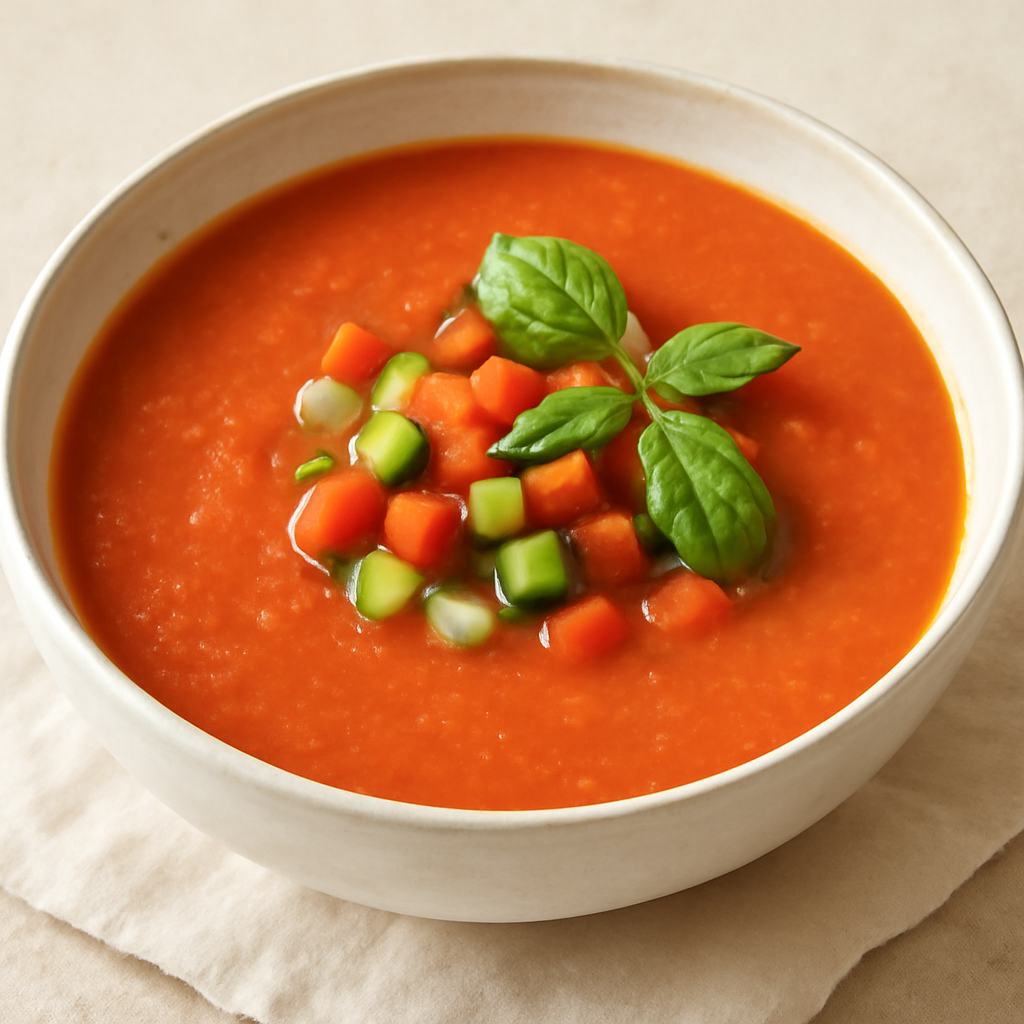

Here are three soups with vibrant colors and inviting presentations:

1. Minestrone (Italy)
- Description: A thick, seasonal vegetable and bean soup bound with a little pasta — different in every kitchen.
- Ingredients: onion, carrots, celery stalks, seasonal vegetables, cannellini beans, tomato, stock, small pasta, Parmesan.
- Preparation: Sweat a soffritto of onion, carrot, and celery in olive oil. Add seasonal vegetables, beans, tomato, and stock. Simmer until everything is tender. Add small pasta near the end; finish with Parmesan.
- Interesting fact: The name means "big soup." There's no fixed recipe — it is made from whatever the garden and larder offer that week.

2. Ratatouille (France)
- Description: A Provençal stew of aubergine, courgette, pepper, and tomato, each cooked to keep its character.
- Ingredients: aubergine, courgettes, bell peppers, tomatoes, onion, garlic cloves, herbes de Provence, olive oil, and basil.
- Preparation: Cook aubergine, courgette, and pepper separ

In [45]:
soup_response = ask_ai("I want a recipe for a soup as image.")

Intermediate response:
prompt='A visually appealing Turkish dessert display featuring a plate of golden-brown baklava, layered with chopped nuts and drizzled with honey, set on a decorative traditional Turkish tablecloth with a backdrop of Ottoman-inspired patterns.' format='image'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, filter_recipe
Step 0: Executing filter_recipe(country='Turkey', include_ingredients=['baklava'], exclude_ingredients=[], top_n=5)...
Step 0: call 1  <-  0 result(s) in 2.4167099998066988
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Generating image...
Generation completed.


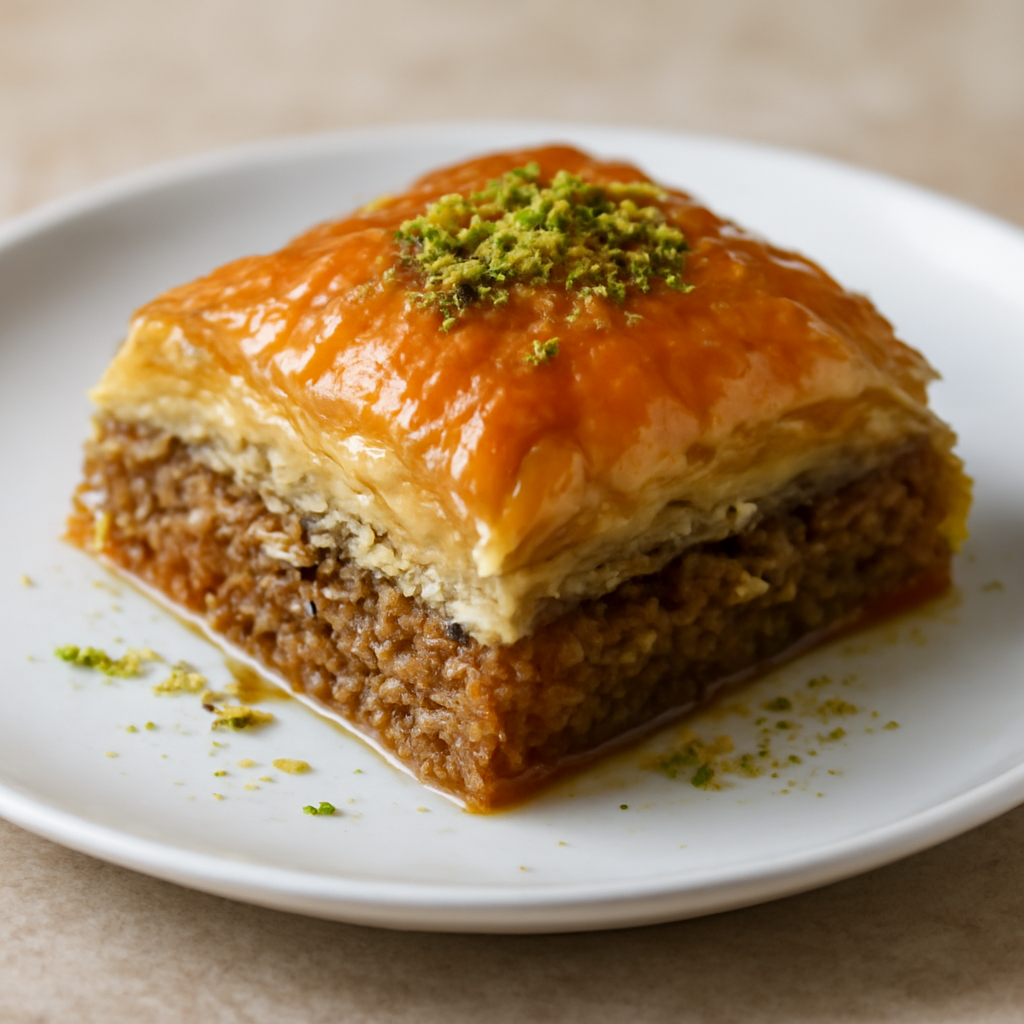

I couldn't find a specific recipe for baklava in the Turkish dessert category in the database. Would you like me to look for a similar Turkish dessert or perhaps another type of dessert that fits your description?


"I couldn't find a specific recipe for baklava in the Turkish dessert category in the database. Would you like me to look for a similar Turkish dessert or perhaps another type of dessert that fits your description?"

In [40]:
ask_ai("Generate image for a dessert that is from Turkey - Baklava or something similar.")

Intermediate response:
prompt='A split image showing two dishes with chicken, arranged side by side for comparison. One dish is a grilled chicken breast with a side of vegetables, and the other is a chicken curry served with rice.' format='image'
Discovered 3 tool call(s) to execute.
Step 0: Found 3, filter_recipe, lookup_recipe, lookup_recipe
Step 0: Executing filter_recipe(country='', include_ingredients=['chicken'], exclude_ingredients=[], top_n=2)...
Step 0: Call filter_recipe <-  2 result(s) in 5.132873000093241
Step 0: Executing lookup_recipe(query='grilled chicken breast with vegetables', top_n=1)...
Step 0: Call lookup_recipe <-  1 result(s) in 207.87411499986774
Step 0: Executing lookup_recipe(query='chicken curry with rice', top_n=1)...
Step 0: Call lookup_recipe <-  1 result(s) in 165.22273200007476
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Generating image...
Generation completed.


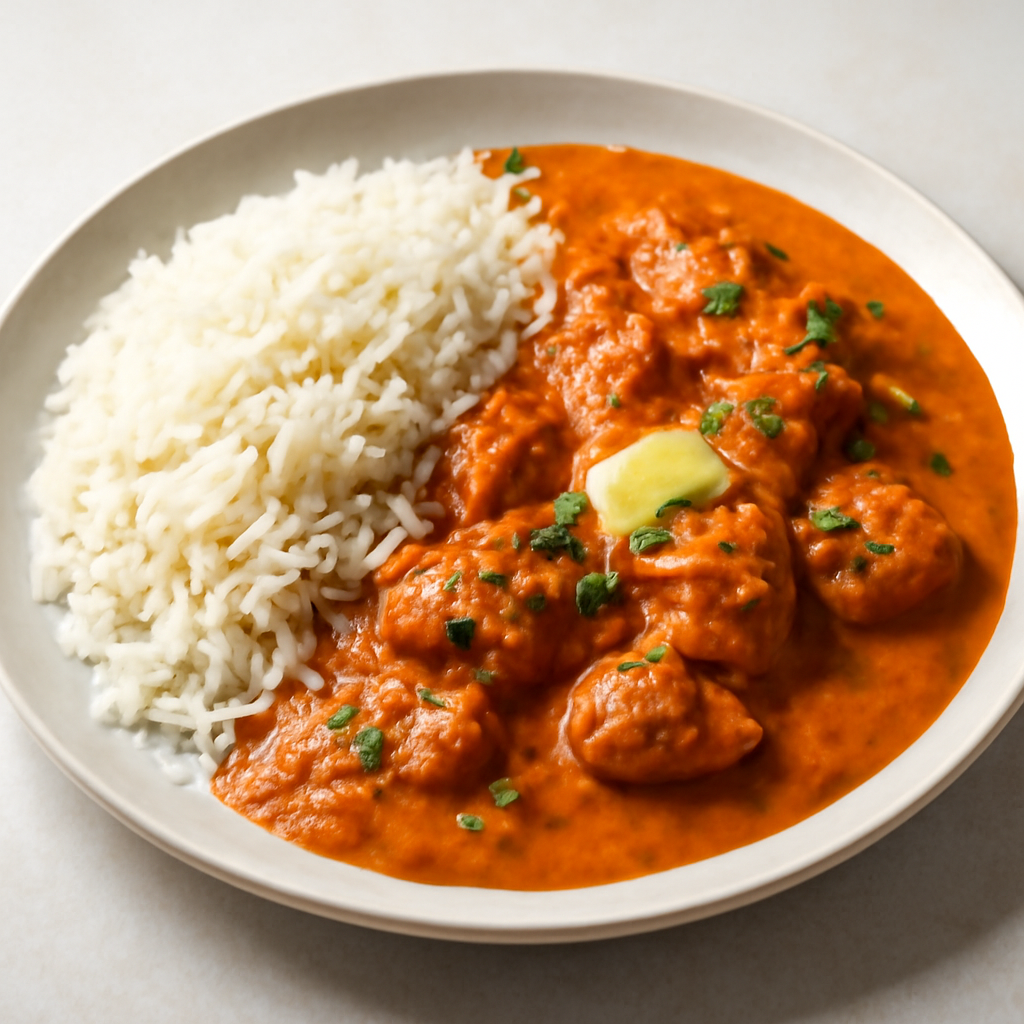

Here are two chicken dishes for comparison from the recipes available:

1. Butter Chicken (Murgh Makhani) from India:
- Description: Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.
- Ingredients: 800 g chicken, 150 g yoghurt, 400 g tomato, 50 g cashews, 60 g butter, 150 ml cream, 2 tbsp garam masala, 1 tbsp kasuri methi.
- Preparation: 
  1. Grill yoghurt-marinated chicken until lightly charred.
  2. Simmer tomato with cashew, butter, cream and spices.
  3. Blend the sauce smooth.
  4. Add the chicken and finish with a knob of butter.
- Interesting fact: It was invented in the 1950s at Delhi's Moti Mahal to use up unsold tandoori chicken—the tomato-butter gravy kept the meat from drying out.

2. Paella Valenciana from Spain (contains chicken and can be served with vegetables):
- Description: Saffron rice cooked flat and wide over fire, prized for the crisp socarrat at the bottom.
- Ingredients: 400 g bomba rice, 500 g chicken or rabbit, 150 g green beans, 1 t

"Here are two chicken dishes for comparison from the recipes available:\n\n1. Butter Chicken (Murgh Makhani) from India:\n- Description: Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.\n- Ingredients: 800 g chicken, 150 g yoghurt, 400 g tomato, 50 g cashews, 60 g butter, 150 ml cream, 2 tbsp garam masala, 1 tbsp kasuri methi.\n- Preparation: \n  1. Grill yoghurt-marinated chicken until lightly charred.\n  2. Simmer tomato with cashew, butter, cream and spices.\n  3. Blend the sauce smooth.\n  4. Add the chicken and finish with a knob of butter.\n- Interesting fact: It was invented in the 1950s at Delhi's Moti Mahal to use up unsold tandoori chicken—the tomato-butter gravy kept the meat from drying out.\n\n2. Paella Valenciana from Spain (contains chicken and can be served with vegetables):\n- Description: Saffron rice cooked flat and wide over fire, prized for the crisp socarrat at the bottom.\n- Ingredients: 400 g bomba rice, 500 g chicken or rabbit, 150 g g

In [46]:
ask_ai("I want an image of 2 dishes with chicken. The result should be in one picture as comparison. ")

Intermediate response:
question='Create a detailed and visually appealing image of Spaghetti alla Carbonara, highlighting the creamy sauce, pancetta, and grated cheese.' format='image'
Loading lookup_recipe tool....
Generating image...


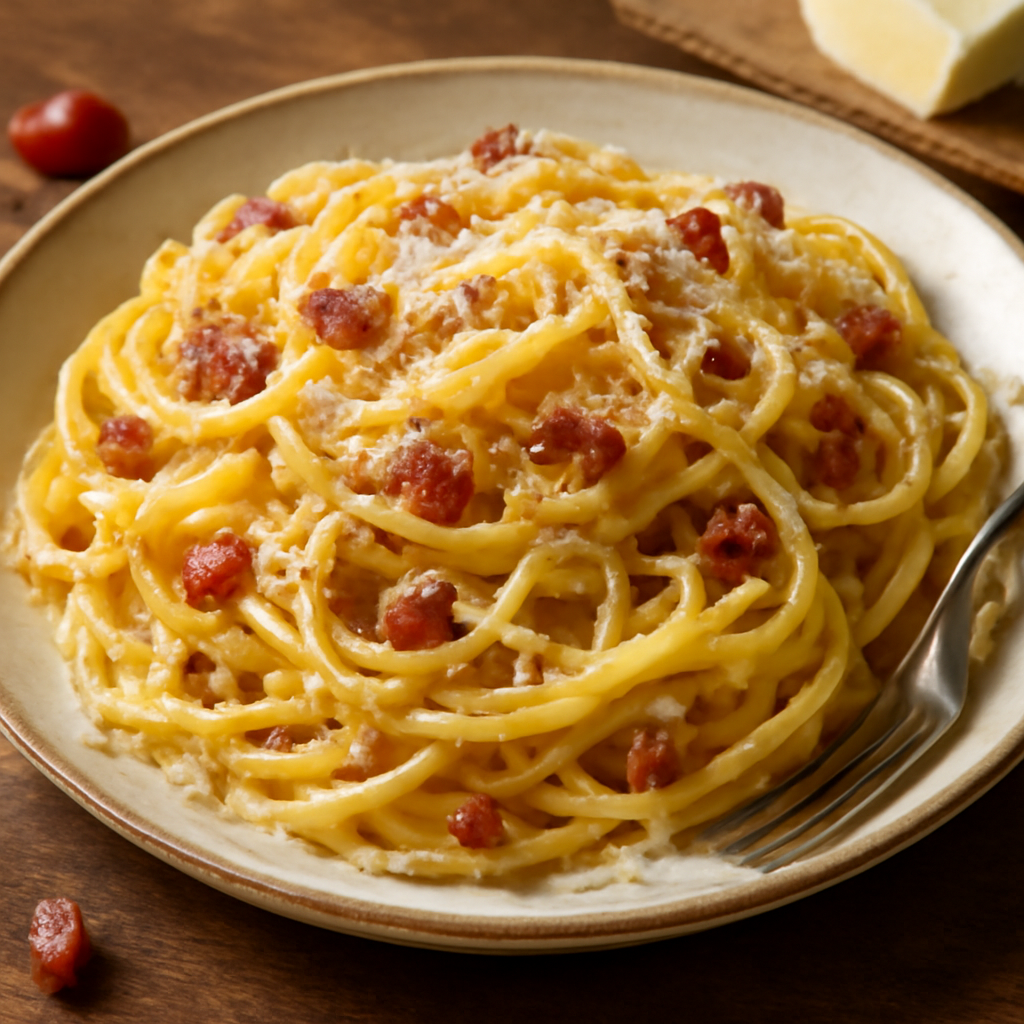


name: Spaghetti alla Carbonara
description: Pasta bound in a glossy sauce of egg, Pecorino and guanciale — no cream, ever.
ingredients: 400 g spaghetti 150 g guanciale 3 eggs + 1 yolk 70 g Pecorino Romano 1 tsp black pepper
preparation: 1. Crisp diced guanciale in its own fat. 2. Whisk eggs with grated Pecorino and lots of black pepper. 3. Toss hot drained pasta with the pork, off the heat. 4. Add the egg mix with pasta water, tossing to a cream.
facts: The "cream" is only egg and cheese emulsified with starchy water. Roman cooks insist the pan comes off the heat or you get scrambled eggs. Goulash (Gulyás) Hungary A paprika-rich beef and onion stew, somewhere between a soup and a braise.


In [28]:
ask_ai("Spaghetti alla Carbonara image")

In [47]:
ask_ai("I want to read to me ingrediants of the recipe for chicken soup or something similar")

Intermediate response:
prompt='List of ingredients for chicken soup or a similar soup recipe.' format='text'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, lookup_recipe
Step 0: Executing lookup_recipe(query='chicken soup or a similar soup', top_n=3)...
Step 0: Call lookup_recipe <-  3 result(s) in 329.43857600002957
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Here are three soup recipes that are similar to chicken soup:

1. Minestrone (Italy)
Description: A thick, seasonal vegetable and bean soup bound with a little pasta—different in every kitchen.
Ingredients: 1 onion, 2 carrots, 2 celery stalks, 300 g seasonal vegetables, 400 g cannellini beans, 400 g tomato, 1.5 l stock, 100 g small pasta, 40 g Parmesan.
Preparation: Sweat a soffritto of onion, carrot, and celery in olive oil. Add seasonal vegetables, beans, tomato, and stock. Simmer until everything is tender. Add small pasta near the end; finish with Parmesan.
Interesting fact: The name simply means "big

'Here are three soup recipes that are similar to chicken soup:\n\n1. Minestrone (Italy)\nDescription: A thick, seasonal vegetable and bean soup bound with a little pasta—different in every kitchen.\nIngredients: 1 onion, 2 carrots, 2 celery stalks, 300 g seasonal vegetables, 400 g cannellini beans, 400 g tomato, 1.5 l stock, 100 g small pasta, 40 g Parmesan.\nPreparation: Sweat a soffritto of onion, carrot, and celery in olive oil. Add seasonal vegetables, beans, tomato, and stock. Simmer until everything is tender. Add small pasta near the end; finish with Parmesan.\nInteresting fact: The name simply means "big soup." There\'s no fixed recipe—it was built from whatever the garden and larder offered that week.\n\n2. Gazpacho Andaluz (Spain)\nDescription: A chilled raw-vegetable soup of tomato, cucumber, pepper, and bread, blitzed with sherry vinegar and oil.\nIngredients: 1 kg ripe tomatoes, 1 cucumber, 1 green pepper, 1 garlic clove, 50 g stale bread, 4 tbsp olive oil, 2 tbsp sherry v

In [48]:
ask_ai("Recipe of Spaghetti alla Carbonara - speech")

Intermediate response:
prompt='Recipe of Spaghetti alla Carbonara' format='speech'
Discovered 1 tool call(s) to execute.
Step 0: Found 1, lookup_recipe
Step 0: Executing lookup_recipe(query='Spaghetti alla Carbonara', top_n=1)...
Step 0: Call lookup_recipe <-  1 result(s) in 322.8615330003777
Discovered 0 tool call(s) to execute.
Step 1: No tool calls.
Generating speech...


Generation completed.
Here is the recipe for Spaghetti alla Carbonara from Italy:

Description:
Pasta bound in a glossy sauce of egg, Pecorino, and guanciale — no cream, ever.

Ingredients:
- 400 g spaghetti
- 150 g guanciale
- 3 eggs + 1 yolk
- 70 g Pecorino Romano
- 1 tsp black pepper

Preparation:
1. Crisp diced guanciale in its own fat.
2. Whisk eggs with grated Pecorino and lots of black pepper.
3. Toss hot drained pasta with the pork, off the heat.
4. Add the egg mix with pasta water, tossing to a cream.

Interesting Fact:
The "cream" of the sauce is only egg and cheese emulsified with starchy water. Roman cooks insist the pan comes off the heat or you get scrambled eggs.

Enjoy making this classic Roman dish!


'Here is the recipe for Spaghetti alla Carbonara from Italy:\n\nDescription:\nPasta bound in a glossy sauce of egg, Pecorino, and guanciale — no cream, ever.\n\nIngredients:\n- 400 g spaghetti\n- 150 g guanciale\n- 3 eggs + 1 yolk\n- 70 g Pecorino Romano\n- 1 tsp black pepper\n\nPreparation:\n1. Crisp diced guanciale in its own fat.\n2. Whisk eggs with grated Pecorino and lots of black pepper.\n3. Toss hot drained pasta with the pork, off the heat.\n4. Add the egg mix with pasta water, tossing to a cream.\n\nInteresting Fact:\nThe "cream" of the sauce is only egg and cheese emulsified with starchy water. Roman cooks insist the pan comes off the heat or you get scrambled eggs.\n\nEnjoy making this classic Roman dish!'